In [ ]:
import experiments.utils_graph as utils_graph
import json
import matplotlib.pyplot as plt
from datetime import time
import numpy as np
from bezierv.classes.distfit import DistFit
import pickle as pkl
# set seed for reproducibility
rng = np.random.default_rng(42)

In [ ]:
data = utils_graph.load_json(r'data/Chicago_main.json')
start_time = time(6, 0)
end_time = time(10, 0)
preprocessed = utils_graph.preprocess_data(data, start_time, end_time)

Generating travel times: 100%|██████████| 1297/1297 [00:00<00:00, 24769.77it/s]


In [5]:
cleaned = {str(k): v["travel_time"] for k, v in preprocessed.items() if "travel_time" in v}

# dump to disk (tuple keys were stringified because JSON keys must be strings)
with open("travel_times.json", "w", encoding="utf-8") as f:
    json.dump(cleaned, f, indent=2)

## Link Examples

In [ ]:
data = utils_graph.load_json(r'data/Chicago_main.json')
start_time = time(6, 0)
end_time = time(10, 0)
preprocessed_peak = utils_graph.preprocess_data(data, start_time, end_time)
start_time = time(15, 0)
end_time = time(20, 0)
preprocessed_afternoonpeak = utils_graph.preprocess_data(data, start_time, end_time)
start_time = time(10, 0)
end_time = time(15, 0)
preprocessed_midday = utils_graph.preprocess_data(data, start_time, end_time)

Generating travel times: 100%|██████████| 1297/1297 [00:00<00:00, 22775.28it/s]


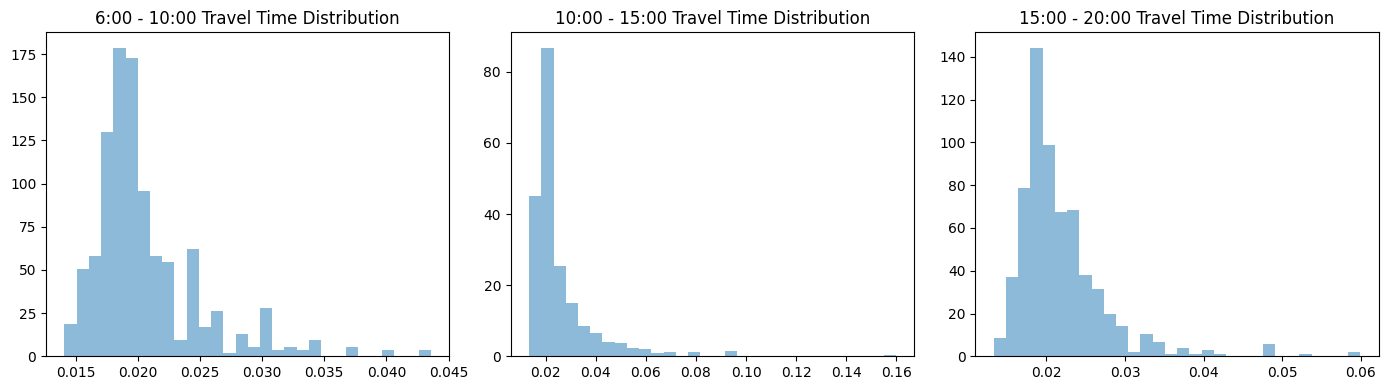

In [7]:
key = (26, 39) #(26, 39)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
ax1.hist(preprocessed_peak[key]['travel_time'], bins=30, density=True, alpha=0.5, label='Peak')
ax2.hist(preprocessed_midday[key]['travel_time'], bins=30, density=True, alpha=0.5, label='Off-Peak')
ax3.hist(preprocessed_afternoonpeak[key]['travel_time'], bins=30, density=True, alpha=0.5, label='Full Day')
ax1.set_title('6:00 - 10:00 Travel Time Distribution')
ax2.set_title('10:00 - 15:00 Travel Time Distribution')
ax3.set_title('15:00 - 20:00 Travel Time Distribution')

fig.tight_layout()
plt.show()

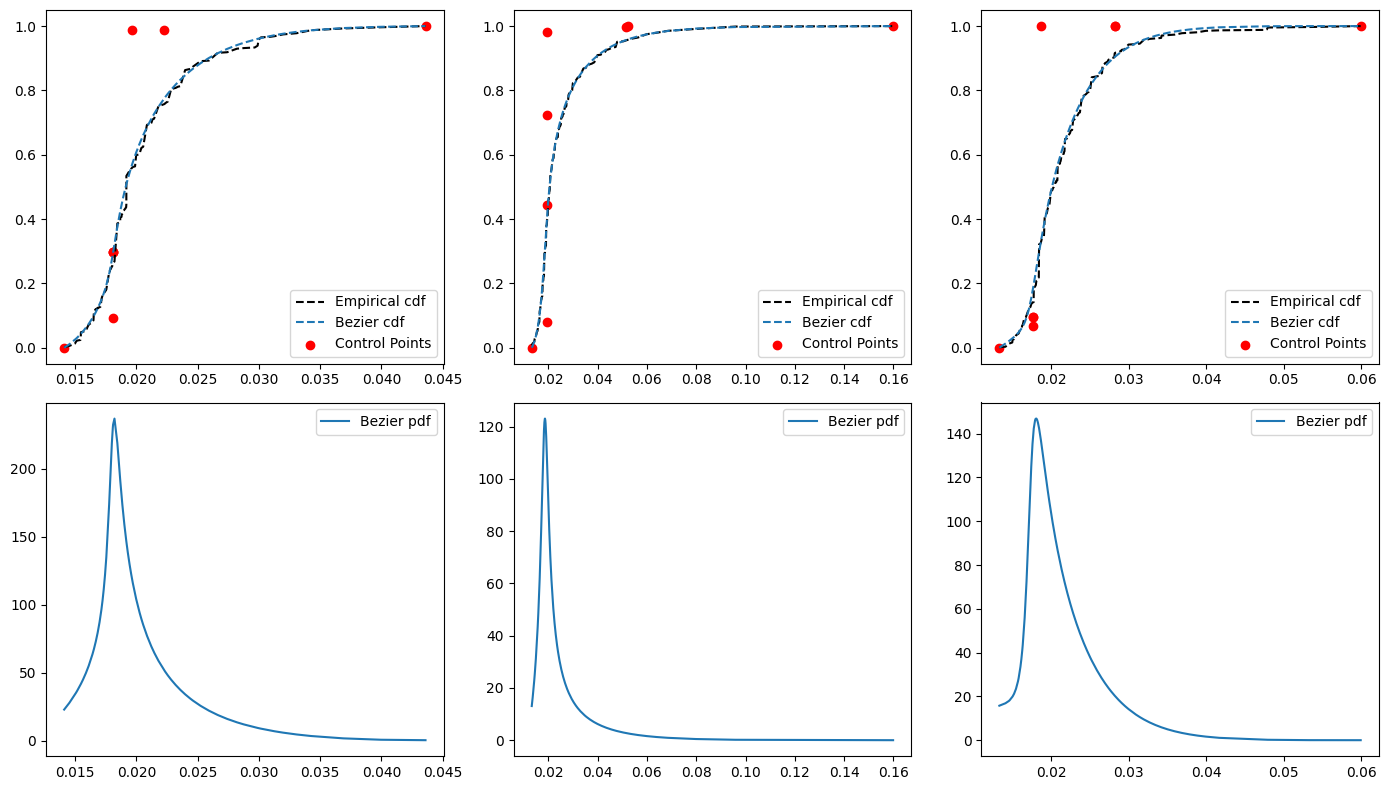

In [8]:
n = 7
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
distfit = DistFit(preprocessed_peak[key]['travel_time'], n=n)
bezierv, _ = distfit.fit(method='nonlinear')
bezierv.plot_cdf(ax=axes[0,0], data=np.sort(preprocessed_peak[key]['travel_time']))
bezierv.plot_pdf(ax=axes[1,0], data=np.sort(preprocessed_peak[key]['travel_time']))
distfit = DistFit(preprocessed_midday[key]['travel_time'], n=n)
bezierv, _ = distfit.fit(method='nonlinear')
bezierv.plot_cdf(ax=axes[0,1], data=np.sort(preprocessed_midday[key]['travel_time']))
bezierv.plot_pdf(ax=axes[1,1], data=np.sort(preprocessed_midday[key]['travel_time']))
distfit = DistFit(preprocessed_afternoonpeak[key]['travel_time'], n=n)
bezierv, _ = distfit.fit(method='nonlinear')
bezierv.plot_cdf(ax=axes[0,2], data=np.sort(preprocessed_afternoonpeak[key]['travel_time']))
bezierv.plot_pdf(ax=axes[1,2], data=np.sort(preprocessed_afternoonpeak[key]['travel_time']))
fig.tight_layout()
plt.show()

## Overall Fitting

In [4]:
n = 7 # control points
k = 1e6 # number of samples (large for better approximation)

In [ ]:
graph_projgrad, projgrad_errors, projgrad_time = utils_graph.fit_graph(preprocessed, n, k, method='projgrad', step_size_PG=1e-2, max_iter_PG=200)
graph_subgrad, subgrad_errors, subgrad_times = utils_graph.fit_graph(preprocessed, n, k, method='projsubgrad', step_size_PS=1e-2, max_iter_PS=200)
graph_nonlinear, nonlinear_errors, nonlinear_times = utils_graph.fit_graph(preprocessed, n, k, method='nonlinear')
graph_nelder, nelder_errors, nelder_times = utils_graph.fit_graph(preprocessed, n, k, method='neldermead', max_iter_NM=200)

Fitting graph links:  15%|█▌        | 196/1297 [01:17<06:57,  2.64it/s]

NonLinearSolver [fit]: An exception occurred during model evaluation: Cannot load a SolverResults object with bad status: error
Error fitting Bezierv for link 115 to 459: local variable 'mse' referenced before assignment with method nonlinear
--------------------


Fitting graph links:  23%|██▎       | 298/1297 [01:59<05:38,  2.95it/s]

model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.17\x3a Maximum Number of Iterations
      Exceeded.
Error fitting Bezierv for link 397 to 167: local variable 'mse' referenced before assignment with method nonlinear
--------------------


Fitting graph links:  67%|██████▋   | 863/1297 [05:35<03:02,  2.37it/s]  

...

Fitting graph links:  76%|███████▋  | 990/1297 [06:20<01:48,  2.82it/s]

NonLinearSolver [fit]: An exception occurred during model evaluation: Cannot load a SolverResults object with bad status: error
Error fitting Bezierv for link 530 to 443: local variable 'mse' referenced before assignment with method nonlinear
--------------------


Fitting graph links:  85%|████████▍ | 1098/1297 [07:08<01:09,  2.87it/s]

NonLinearSolver [fit]: An exception occurred during model evaluation: Cannot load a SolverResults object with bad status: error
Error fitting Bezierv for link 354 to 410: local variable 'mse' referenced before assignment with method nonlinear
--------------------


Fitting graph links: 100%|██████████| 1297/1297 [1:21:28<00:00,  3.77s/it]


In [4]:
# load pickles of graphs
with open("data/fitted_graph_projgrad.pkl", "rb") as f:
    graph_projgrad = pkl.load(f)
with open("data/fitted_graph_projsubgrad.pkl", "rb") as f:
    graph_subgrad = pkl.load(f)
with open("data/fitted_graph_nonlinear.pkl", "rb") as f:
    graph_nonlinear = pkl.load(f)
with open("data/fitted_graph_neldermead.pkl", "rb") as f:
    graph_nelder = pkl.load(f)
with open("data/fitted_errors_projgrad.pkl", "rb") as f:
    projgrad_errors = pkl.load(f)
with open("data/fitted_errors_projsubgrad.pkl", "rb") as f:
    subgrad_errors = pkl.load(f)
with open("data/fitted_errors_nonlinear.pkl", "rb") as f:
    nonlinear_errors = pkl.load(f)
with open("data/fitted_errors_neldermead.pkl", "rb") as f:
    nelder_errors = pkl.load(f)
with open("data/fitted_times_projgrad.pkl", "rb") as f:
    projgrad_times = pkl.load(f)
with open("data/fitted_times_projsubgrad.pkl", "rb") as f:
    subgrad_times = pkl.load(f)
with open("data/fitted_times_nonlinear.pkl", "rb") as f:
    nonlinear_times = pkl.load(f)
with open("data/fitted_times_neldermead.pkl", "rb") as f:
    nelder_times = pkl.load(f)

In [29]:
times = [projgrad_times, subgrad_times, nonlinear_times, nelder_times]
errors = [projgrad_errors, subgrad_errors, nonlinear_errors, nelder_errors]
methods = ['ProjGrad', 'ProjSubGrad', 'Nonlinear', 'NelderMead']
# print mean, std, median for each method in scientific notation
for method, time, error in zip(methods, times, errors):
    print(f"{method} - |ELAPSED TIME: mean: {np.mean(time):.2e}, std: {np.std(time):.2e}| MSE: mean: {np.mean(error):.2e}, std: {np.std(error):.2e}|")

ProjGrad - |ELAPSED TIME: mean: 1.64e-01, std: 1.10e-01| MSE: mean: 3.85e-03, std: 4.32e-02|
ProjSubGrad - |ELAPSED TIME: mean: 3.75e+00, std: 6.23e-01| MSE: mean: 7.12e-03, std: 4.83e-02|
Nonlinear - |ELAPSED TIME: mean: 3.52e-01, std: 1.21e-01| MSE: mean: 8.67e-04, std: 7.07e-03|
NelderMead - |ELAPSED TIME: mean: 3.76e+00, std: 6.66e-01| MSE: mean: 6.28e-03, std: 2.39e-02|


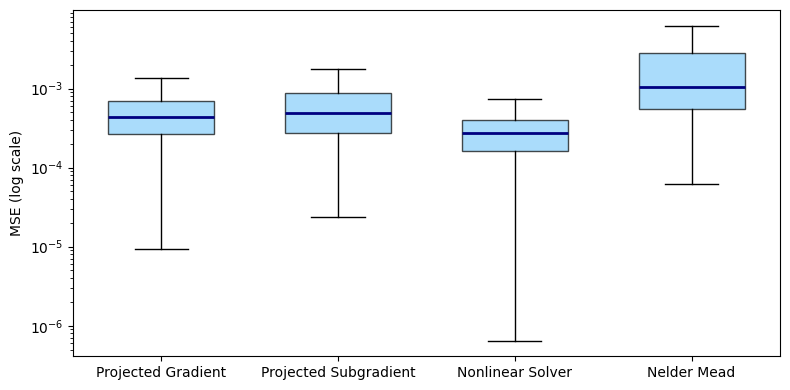

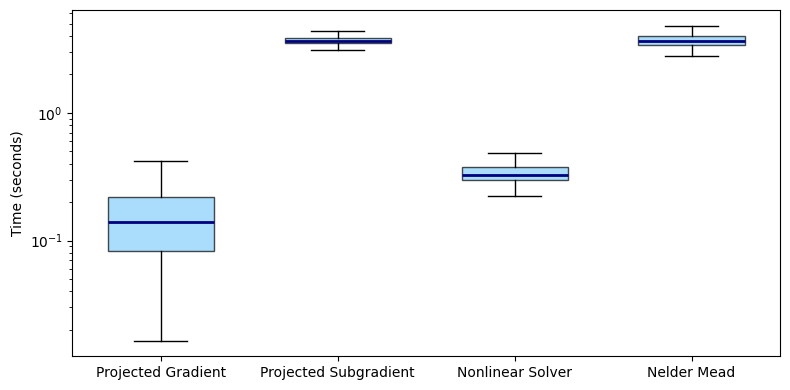

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(
    [projgrad_errors, subgrad_errors, nonlinear_errors, nelder_errors],      # 4 datasets → 4 boxes
    positions=[1, 2, 3, 4],            # where they sit on the x-axis
    widths=0.6,                        # box width
    patch_artist=True,                 # allow facecolor
    boxprops=dict(facecolor="lightskyblue", alpha=0.7),
    medianprops=dict(color="navy", linewidth=2),
    showfliers=False
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Projected Gradient", "Projected Subgradient", "Nonlinear Solver", "Nelder Mead"], fontsize=10)
ax.set_ylabel("MSE (log scale)")
ax.set_yscale("log")           # <-- logarithmic y-axis
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(
    [projgrad_times, subgrad_times, nonlinear_times, nelder_times],      # 4 datasets → 4 boxes
    positions=[1, 2, 3, 4],            # where they sit on the x-axis
    widths=0.6,                        # box width
    patch_artist=True,                 # allow facecolor
    boxprops=dict(facecolor="lightskyblue", alpha=0.7),
    medianprops=dict(color="navy", linewidth=2),
    showfliers=False
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Projected Gradient", "Projected Subgradient", "Nonlinear Solver", "Nelder Mead"], fontsize=10)
ax.set_ylabel("Time (seconds)")
ax.set_yscale("log")           # <-- logarithmic y-axis
plt.tight_layout()
plt.show()



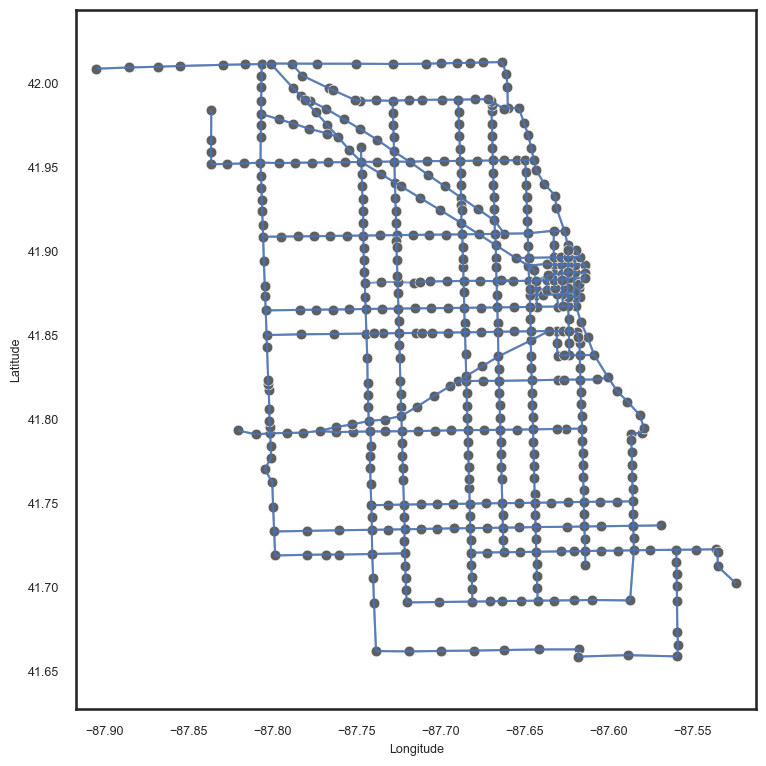

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns

def plot_graph_sns(graph, annotate=False, edge_color=None, figsize=(8, 8)):
    """
    Plot the fitted graph using seaborn styling.

    Parameters
    ----------
    graph : Graph
        Graph returned by `fit_graph`.
    annotate : bool, default True
        Whether to write node ids next to the points.
    edge_color : str or tuple, optional
        Color for all edges. If None, uses first color in seaborn palette.
    figsize : tuple
        Matplotlib figure size.
    """
    # Collect node positions and edges
    positions = {}
    edges = []
    for src_name, src_node in graph.nodes.items():
        for dst_name, link in src_node.links.items():
            d = link.deterministic
            positions[src_name] = (d['start_longitude'], d['start_latitude'])
            positions[dst_name] = (d['end_longitude'], d['end_latitude'])
            edges.append((src_name, dst_name))

    if edge_color is None:
        edge_color = sns.color_palette("deep")[0]

    # Seaborn theme
    sns.set_theme(style="white",context="talk")

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Prepare edges as LineCollection
    lines = [ [positions[u], positions[v]] for u, v in edges ]
    lc = LineCollection(lines, colors=edge_color, linewidths=1.5, alpha=0.7)
    ax.add_collection(lc)

    # Nodes dataframe for seaborn scatter
    nodes_df = pd.DataFrame(
        [{"node": nid, "x": x, "y": y} for nid, (x, y) in positions.items()]
    )
    sns.scatterplot(
        data=nodes_df,
        x="x",
        y="y",
        s=60,
        color="#5E5F60",
        edgecolor="white",
        alpha=1,
        linewidth=0.5,
        ax=ax
    )

    # Annotations
    if annotate:
        for _, row in nodes_df.iterrows():
            ax.text(row.x, row.y, str(row.node), fontsize=6,
                    ha="right", va="bottom")


    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)
    ax.tick_params(axis='both', which='both', labelsize=9)
    #ax.set_title("Chicago Road Network", fontsize=10)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()
    return fig, ax

# Usage:
fig, ax = plot_graph_sns(graph_projgrad, edge_color="#4C72B0")


## Path Fitting

In [5]:
n_sims = 1000

In [ ]:
graph_empirical = utils_graph.get_empirical_graph(preprocessed_afternoonpeak)
graph_phase = utils_graph.get_phase_graph(preprocessed_afternoonpeak, 'data/phase_params.json')

Building empirical graph links: 100%|██████████| 1297/1297 [00:00<00:00, 6852.49it/s]


In [15]:
lens = []
for link in graph_empirical.get_links_info():
    link = graph_empirical.nodes[link[0]].links[link[1]]
    lens.append(len(link.random['time']['samples']))
print(f"Average number of samples per link: {np.mean(lens)}")

Average number of samples per link: 688.993831919815


In [ ]:
start_node = 450
target_node = 500
alpha = 0.9
gamma = 0.5
T_max, shortest_mean_path, cost_min_mean, bezierv_min_mean, shortest_cost_path, cost_min_cost, bezierv_min_cost = utils_graph.get_time_budget_bezierv(graph_projgrad, start_node, target_node, alpha, gamma, n_sims=n_sims, rng=rng)

In [17]:
print(len(shortest_mean_path))

28


In [ ]:
res1 = utils_graph.convolution_experiment(graph_projgrad, graph_empirical, shortest_mean_path[:5], n_sims=n_sims, rng=rng)
res2 = utils_graph.convolution_experiment(graph_projgrad, graph_empirical, shortest_mean_path[:10], n_sims=n_sims, rng=rng)
res3 = utils_graph.convolution_experiment(graph_projgrad, graph_empirical, shortest_mean_path, n_sims=n_sims, rng=rng)

# dump results to disk
with open("data/convolution_results_5.pkl", "wb") as f:
    pkl.dump(res1, f)
with open("data/convolution_results_10.pkl", "wb") as f:
    pkl.dump(res2, f)
with open("data/convolution_results_full.pkl", "wb") as f:
    pkl.dump(res3, f)


In [26]:
mse_res1 = np.mean((res1['cdf_bezierv'] - res1['cdf_montecarlo'])**2)
mse_res2 = np.mean((res2['cdf_bezierv'] - res2['cdf_montecarlo'])**2)
mse_res3 = np.mean((res3['cdf_bezierv'] - res3['cdf_montecarlo'])**2)

# print mse results in scientific notation with e
print(f"MSE for 5 nodes: {mse_res1:.2e}")
print(f"MSE for 10 nodes: {mse_res2:.2e}")
print(f"MSE for full path: {mse_res3:.2e}")

MSE for 5 nodes: 5.92e-04
MSE for 10 nodes: 1.55e-04
MSE for full path: 1.56e-04


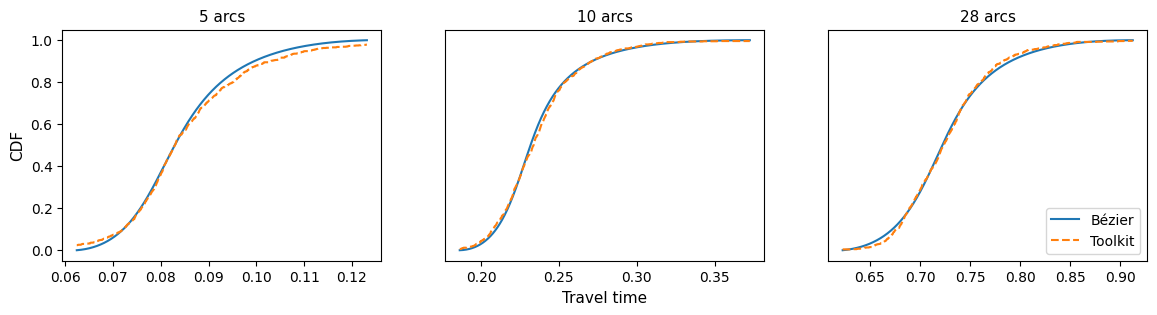

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(res1["x"], res1["cdf_bezierv"], label="Bézier")
axes[0].plot(res1["x"], res1["cdf_montecarlo"], "--", label="Toolkit")
axes[1].plot(res2["x"], res2["cdf_bezierv"], label="Convolution Bézier CDF")
axes[1].plot(res2["x"], res2["cdf_montecarlo"], "--", label="Monte Carlo empirical CDF")
axes[2].plot(res3["x"], res3["cdf_bezierv"], label="Bézier")
axes[2].plot(res3["x"], res3["cdf_montecarlo"], "--", label="Toolkit")

# remove x ticks from the second and third plots
axes[1].set_yticks([])
axes[2].set_yticks([])
axes[0].set_ylabel("CDF", fontsize=11)
axes[1].set_xlabel("Travel time", fontsize=11)
axes[0].set_title("5 arcs", fontsize=11)
axes[1].set_title("10 arcs", fontsize=11)
axes[2].set_title("28 arcs", fontsize=11)
plt.legend(loc='lower right')
plt.show()
# change legend position

